<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
import requests
r = requests.get('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv')
with open('survey-data.csv', 'wb') as f:
    f.write(r.content)

**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [6]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])

CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [10]:
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL;
"""
comp_total = pd.read_sql_query(QUERY, conn)
comp_total.describe()

,CompTotal
count,3.374000e+04
mean,2.963841e+145
std,5.444117e+147
min,0.000000e+00
25%,6.000000e+04
50%,1.100000e+05
75%,2.500000e+05
max,1.000000e+150


In [11]:
# the max value and std dev are ridiculously huge, going to remove outliers via IQR method
q1 = comp_total.quantile(.25)
q3 = comp_total.quantile(.75)
iqr = q3-q1
upper = q3 + iqr * 1.5
comp_total = comp_total[comp_total< upper]
comp_total.describe()

,CompTotal
count,27861.000000
mean,117137.615879
std,99881.615371
min,0.000000
25%,50000.000000
50%,88000.000000
75%,150000.000000
max,534000.000000


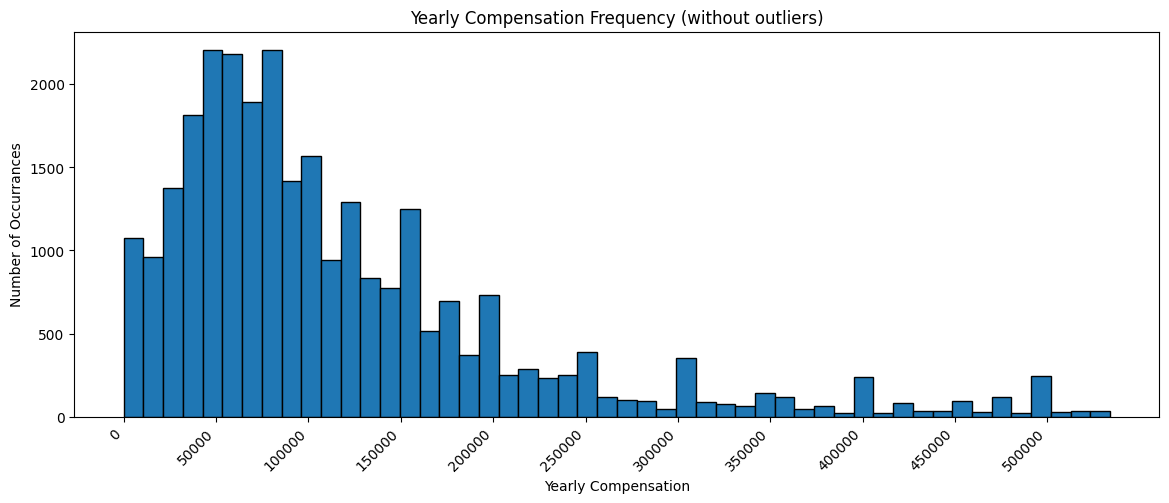

In [12]:
plt.figure(figsize = (14,5))
plt.hist(comp_total, bins = 50, edgecolor='black')
plt.xlabel('Yearly Compensation')
plt.ylabel('Number of Occurrances')
plt.title('Yearly Compensation Frequency (without outliers)')
plt.xticks(ticks = range(0, 550000, 50000), rotation = 45, ha='right')
plt.show()

**Box Plots**

Plot a box plot of Age.


In [13]:
#age = pd.DataFrame([df['Age'].value_counts()])
#age
QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL AND
Age != 'Prefer not to say';
"""
df_age = pd.read_sql_query(QUERY, conn)

In [14]:
df_age.value_counts()

Age               
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Name: count, dtype: int64

In [15]:
df_age['Age'] = df_age['Age'].replace('Under 18 years old', 16)
df_age['Age'] = df_age['Age'].replace('65 years or older', 67)
df_age['Age'] = df_age['Age'].replace('25-34 years old', 29)
df_age['Age'] = df_age['Age'].replace('35-44 years old', 39)
df_age['Age'] = df_age['Age'].replace('18-24 years old', 21)
df_age['Age'] = df_age['Age'].replace('45-54 years old', 49)
df_age['Age'] = df_age['Age'].replace('55-64 years old', 60)

df_age.value_counts()

Age
29     23911
39     14942
21     14098
49      6249
60      2575
16      2568
67       772
Name: count, dtype: int64

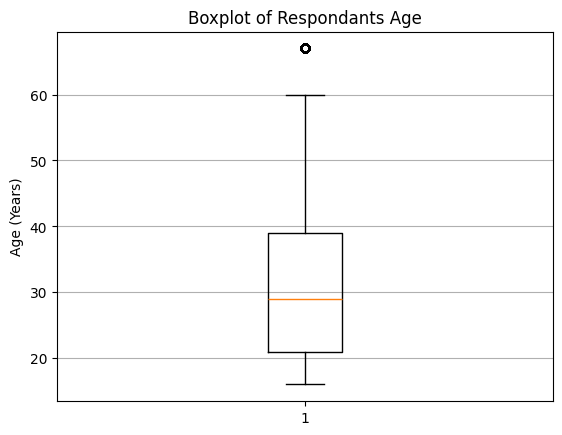

In [16]:
plt.boxplot(df_age['Age'])
plt.ylabel('Age (Years)')
plt.grid(visible = True, axis = 'y')
plt.title('Boxplot of Respondants Age')
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


In [17]:
QUERY = """
SELECT Age, WorkExp
FROM main
WHERE Age IS NOT NULL AND
Age != 'Prefer not to say' AND
WorkExp IS NOT NULL;
"""
df_age_workexp = pd.read_sql_query(QUERY, conn)
df_age_workexp.head()

,Age,WorkExp
0,35-44 years old,17.0
1,35-44 years old,15.0
2,35-44 years old,12.0
3,45-54 years old,29.0
4,25-34 years old,12.0


In [18]:
df_age_workexp['Age'] = df_age_workexp['Age'].replace('Under 18 years old', 16)
df_age_workexp['Age'] = df_age_workexp['Age'].replace('65 years or older', 67)
df_age_workexp['Age'] = df_age_workexp['Age'].replace('25-34 years old', 29)
df_age_workexp['Age'] = df_age_workexp['Age'].replace('35-44 years old', 39)
df_age_workexp['Age'] = df_age_workexp['Age'].replace('18-24 years old', 21)
df_age_workexp['Age'] = df_age_workexp['Age'].replace('45-54 years old', 49)
df_age_workexp['Age'] = df_age_workexp['Age'].replace('55-64 years old', 60)

In [19]:
df_age_workexp[df_age_workexp['WorkExp'] == 50]

,Age,WorkExp
430,67,50.0
540,60,50.0
939,67,50.0
1171,67,50.0
1422,60,50.0
3608,67,50.0
4526,29,50.0
6327,21,50.0
6803,67,50.0
6938,29,50.0


In [20]:
# some rows contain impossibilities, i.e. workexp > age
# used 13 as a reasonable age one could have possibly begun professional work
df_age_workexp = df_age_workexp.drop(df_age_workexp[(df_age_workexp['Age'] - df_age_workexp['WorkExp'] < 13)].index) # removing said rows
df_age_workexp[df_age_workexp['WorkExp'] == 50] # checking the values

,Age,WorkExp
430,67,50.0
939,67,50.0
1171,67,50.0
3608,67,50.0
6803,67,50.0
9556,67,50.0
10133,67,50.0
10233,67,50.0
10491,67,50.0
11015,67,50.0


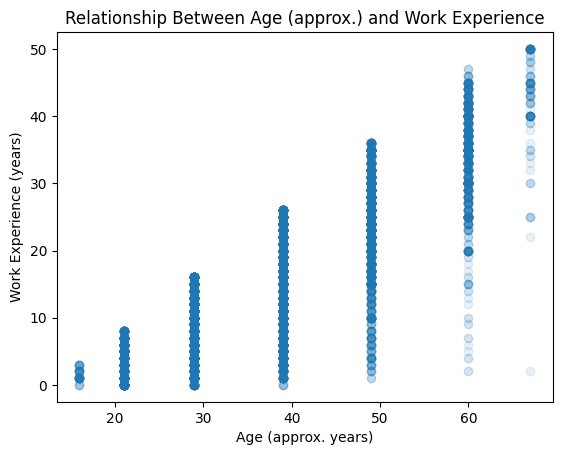

In [21]:
plt.scatter(x = df_age_workexp['Age'],
            y = df_age_workexp['WorkExp'],
            alpha = 0.1) # want maximum opacity as they darken upon overlap, all would look the same without a hint of number of occurances
plt.xlabel('Age (approx. years)')
plt.ylabel('Work Experience (years)')
plt.title('Relationship Between Age (approx.) and Work Experience')
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [22]:
QUERY = """SELECT Age, TimeSearching, Frustration
FROM main
WHERE Age IS NOT NULL
AND TimeSearching IS NOT NULL
AND Frustration IS NOT NULL
AND Age != 'Prefer not to say';
"""
df_bubble = pd.read_sql_query(QUERY, conn)
df_bubble

,Age,TimeSearching,Frustration
0,35-44 years old,30-60 minutes a day,Amount of technical debt;Number of software to...
1,35-44 years old,30-60 minutes a day,Amount of technical debt;Complexity of tech st...
2,45-54 years old,60-120 minutes a day,Amount of technical debt;Complexity of tech st...
3,25-34 years old,15-30 minutes a day,Amount of technical debt;Tracking my work;Comp...
4,25-34 years old,Less than 15 minutes a day,Number of software tools in use;Tracking my wo...
...,...,...,...
28033,25-34 years old,60-120 minutes a day,Amount of technical debt;Showing my contributi...
28034,18-24 years old,60-120 minutes a day,Tracking my work;Complexity of tech stack for ...
28035,25-34 years old,Less than 15 minutes a day,None of these
28036,25-34 years old,15-30 minutes a day,Complexity of tech stack for deployment;Comple...


In [23]:
df_bubble['Frustration_Level'] = df_bubble['Frustration'].str.split(';').apply(len) # assigning the length (# of items in the string) to a 'frustration level'

In [24]:
df_bubble

,Age,TimeSearching,Frustration,Frustration_Level
0,35-44 years old,30-60 minutes a day,Amount of technical debt;Number of software to...,4
1,35-44 years old,30-60 minutes a day,Amount of technical debt;Complexity of tech st...,2
2,45-54 years old,60-120 minutes a day,Amount of technical debt;Complexity of tech st...,4
3,25-34 years old,15-30 minutes a day,Amount of technical debt;Tracking my work;Comp...,6
4,25-34 years old,Less than 15 minutes a day,Number of software tools in use;Tracking my wo...,4
...,...,...,...,...
28033,25-34 years old,60-120 minutes a day,Amount of technical debt;Showing my contributi...,3
28034,18-24 years old,60-120 minutes a day,Tracking my work;Complexity of tech stack for ...,2
28035,25-34 years old,Less than 15 minutes a day,None of these,1
28036,25-34 years old,15-30 minutes a day,Complexity of tech stack for deployment;Comple...,2


In [25]:
df_bubble['Age'] = df_bubble['Age'].map({'Under 18 years old': 16,
                                         '65 years or older': 67,
                                         '25-34 years old': 29,
                                         '35-44 years old': 39,
                                         '18-24 years old': 21,
                                         '45-54 years old': 49,
                                         '55-64 years old': 60})
df_bubble

,Age,TimeSearching,Frustration,Frustration_Level
0,39,30-60 minutes a day,Amount of technical debt;Number of software to...,4
1,39,30-60 minutes a day,Amount of technical debt;Complexity of tech st...,2
2,49,60-120 minutes a day,Amount of technical debt;Complexity of tech st...,4
3,29,15-30 minutes a day,Amount of technical debt;Tracking my work;Comp...,6
4,29,Less than 15 minutes a day,Number of software tools in use;Tracking my wo...,4
...,...,...,...,...
28033,29,60-120 minutes a day,Amount of technical debt;Showing my contributi...,3
28034,21,60-120 minutes a day,Tracking my work;Complexity of tech stack for ...,2
28035,29,Less than 15 minutes a day,None of these,1
28036,29,15-30 minutes a day,Complexity of tech stack for deployment;Comple...,2


In [26]:
df_bubble['TimeSearching'] = df_bubble['TimeSearching'].map({'Less than 15 minutes a day': .12,
                                                             '15-30 minutes a day': .37,
                                                             '30-60 minutes a day': .75,
                                                             '60-120 minutes a day': 1.5,
                                                             'Over 120 minutes a day': 2.5})
df_bubble

,Age,TimeSearching,Frustration,Frustration_Level
0,39,0.75,Amount of technical debt;Number of software to...,4
1,39,0.75,Amount of technical debt;Complexity of tech st...,2
2,49,1.50,Amount of technical debt;Complexity of tech st...,4
3,29,0.37,Amount of technical debt;Tracking my work;Comp...,6
4,29,0.12,Number of software tools in use;Tracking my wo...,4
...,...,...,...,...
28033,29,1.50,Amount of technical debt;Showing my contributi...,3
28034,21,1.50,Tracking my work;Complexity of tech stack for ...,2
28035,29,0.12,None of these,1
28036,29,0.37,Complexity of tech stack for deployment;Comple...,2


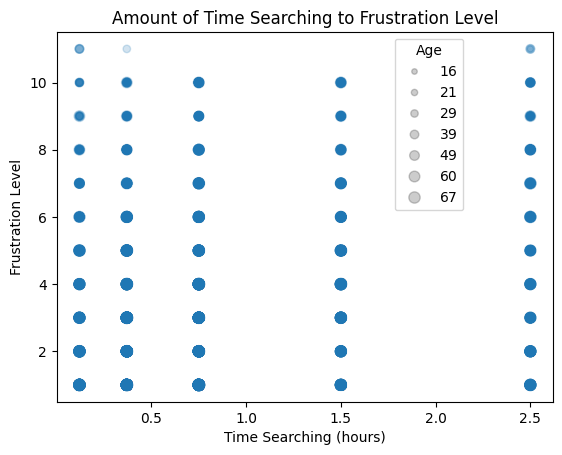

In [27]:
fig, ax = plt.subplots()

scatter = ax.scatter(x = df_bubble['TimeSearching'],
                     y = df_bubble['Frustration_Level'],
                     s = df_bubble['Age'],
                     alpha = 0.2,
                     label = list(df_bubble['Age'].value_counts().index))

legend = ax.legend(*scatter.legend_elements(prop = 'sizes'),
                   loc="center", bbox_to_anchor= (0.75, 0.75), title='Age')

plt.xlabel('Time Searching (hours)')
plt.ylabel('Frustration Level')
plt.title('Amount of Time Searching to Frustration Level')
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


In [28]:
QUERY = """SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL;
"""
df_db_want = pd.read_sql_query(QUERY, conn)

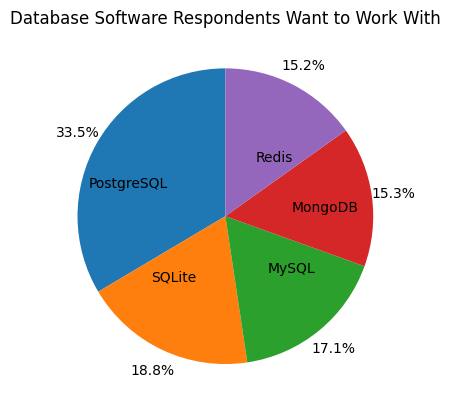

In [29]:
df_pie = df_db_want['DatabaseWantToWorkWith'].str.split(';').explode().value_counts().head(5)
plt.pie(df_pie, labels = df_pie.index, autopct='%1.1f%%', startangle=90,
        pctdistance=1.15, labeldistance=.45) # easier to absorb with names in the pie
plt.title('Database Software Respondents Want to Work With')
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


In [30]:
QUERY = """SELECT TimeSearching, TimeAnswering, Age
FROM main
WHERE TimeSearching IS NOT NULL
AND TimeAnswering IS NOT NULL
AND Age == '25-34 years old';
"""
df_stacked = pd.read_sql_query(QUERY, conn)
df_stacked

,TimeSearching,TimeAnswering,Age
0,15-30 minutes a day,30-60 minutes a day,25-34 years old
1,Less than 15 minutes a day,15-30 minutes a day,25-34 years old
2,60-120 minutes a day,15-30 minutes a day,25-34 years old
3,60-120 minutes a day,15-30 minutes a day,25-34 years old
4,30-60 minutes a day,15-30 minutes a day,25-34 years old
...,...,...,...
12514,15-30 minutes a day,15-30 minutes a day,25-34 years old
12515,60-120 minutes a day,15-30 minutes a day,25-34 years old
12516,60-120 minutes a day,30-60 minutes a day,25-34 years old
12517,Less than 15 minutes a day,Less than 15 minutes a day,25-34 years old


In [31]:
rows_to_remove = df_stacked.sample(frac = 0.4).index # we only want ages 30-35, which is about .5 of 25-34 and .1 of 35-49, selecting 40% of rows at random to drop
df_stacked = df_stacked.drop(rows_to_remove) # dropping 40% of the rows selected in the sampling
df_stacked

,TimeSearching,TimeAnswering,Age
0,15-30 minutes a day,30-60 minutes a day,25-34 years old
1,Less than 15 minutes a day,15-30 minutes a day,25-34 years old
2,60-120 minutes a day,15-30 minutes a day,25-34 years old
3,60-120 minutes a day,15-30 minutes a day,25-34 years old
4,30-60 minutes a day,15-30 minutes a day,25-34 years old
...,...,...,...
12510,30-60 minutes a day,Over 120 minutes a day,25-34 years old
12511,30-60 minutes a day,15-30 minutes a day,25-34 years old
12512,30-60 minutes a day,60-120 minutes a day,25-34 years old
12514,15-30 minutes a day,15-30 minutes a day,25-34 years old


In [32]:
df_stacked['TimeSearching']

0               15-30 minutes a day
1        Less than 15 minutes a day
2              60-120 minutes a day
3              60-120 minutes a day
4               30-60 minutes a day
                    ...            
12510           30-60 minutes a day
12511           30-60 minutes a day
12512           30-60 minutes a day
12514           15-30 minutes a day
12515          60-120 minutes a day
Name: TimeSearching, Length: 7511, dtype: str

In [33]:
import numpy as np
categories = ["Less than 15 minutes a day", "15-30 minutes a day", "30-60 minutes a day", "60-120 minutes a day", "Over 120 minutes a day"] # create categories for integer coding
df_stacked['TimeSearching'] = pd.Categorical(df_stacked['TimeSearching'], categories, ordered=True) # storing as category datatype
df_stacked['TimeAnswering'] = pd.Categorical(df_stacked['TimeAnswering'], categories, ordered=True) # storing as category datatype
median_search_value = int(np.median(df_stacked['TimeSearching'].cat.codes)) # finding the median of the categories with integer representation, 0-4 in same order as 'categories'
median_answer_value = int(np.median(df_stacked['TimeAnswering'].cat.codes)) # finding the median of the categories with integer representation, 0-4 in same order as 'categories'

In [34]:
print(f'Median of time answering: {categories[median_answer_value]}, category {median_answer_value}',
      f'\nMedian of time searching: {categories[median_search_value]}, category {median_search_value}') # showing the categories that are the medians

Median of time answering: 15-30 minutes a day, category 1 
Median of time searching: 30-60 minutes a day, category 2


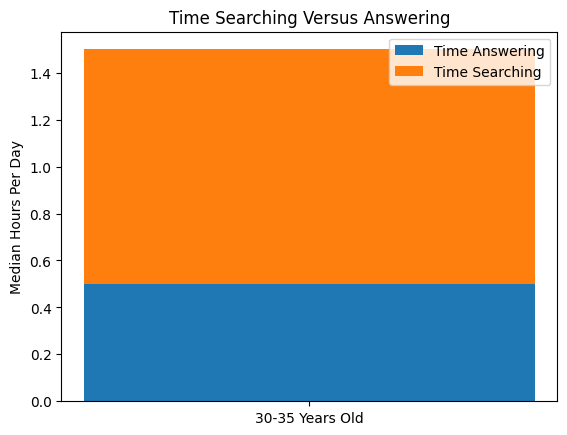

In [35]:
fig, ax = plt.subplots()

ax.bar(['30-35 Years Old'], median_answer_value/2, label = 'Time Answering') # the category integer value happens to be double of the number of hours it represents
ax.bar(['30-35 Years Old'], median_search_value/2, bottom=median_answer_value/2, label = 'Time Searching') # the category integer happens to be double of the number of hours represented
plt.title('Time Searching Versus Answering')
plt.ylabel('Median Hours Per Day')
plt.legend(loc='upper right')
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


In [36]:
QUERY = """SELECT CompTotal, Age
FROM main
WHERE CompTotal IS NOT NULL 
AND Age IS NOT NULL 
AND (Age == '45-54 years old' OR Age == '55-64 years old');
"""
df_line = pd.read_sql_query(QUERY, conn)
df_line

,CompTotal,Age
0,95000.0,45-54 years old
1,195000.0,45-54 years old
2,54000.0,55-64 years old
3,145000.0,45-54 years old
4,80000.0,55-64 years old
...,...,...
4790,40000.0,45-54 years old
4791,250000.0,45-54 years old
4792,250000.0,45-54 years old
4793,157000.0,45-54 years old


In [37]:
df_line[(df_line['Age']=='55-64 years old')].shape # verifying number of rows with 55-64 before sample drop

(1279, 2)

In [38]:
rows_to_drop = df_line[(df_line['Age']=='55-64 years old')].sample(frac= 0.4).index # ages 61-64 is .4 of the range, going to drop 40% of those rows
df_line = df_line.drop(rows_to_drop)
df_line[(df_line['Age']=='55-64 years old')].shape # verifying number of rows with 55-64 after sample drop

(767, 2)

In [39]:
df_line

,CompTotal,Age
0,95000.0,45-54 years old
1,195000.0,45-54 years old
3,145000.0,45-54 years old
6,115000.0,45-54 years old
7,300000.0,45-54 years old
...,...,...
4790,40000.0,45-54 years old
4791,250000.0,45-54 years old
4792,250000.0,45-54 years old
4793,157000.0,45-54 years old


In [40]:
labels, uniques = pd.factorize(df_line['Age'])
print(f'Labels:{labels}\nCategories: {uniques}\nLabel {labels[0]}: {uniques[0]}\nLabel {labels[2]}: {uniques[1]}')

Labels:[0 0 0 ... 0 0 0]
Categories: Index(['45-54 years old', '55-64 years old'], dtype='str')
Label 0: 45-54 years old
Label 0: 55-64 years old


In [41]:
df_line['Age'] = labels
df_line['Age'] = df_line['Age'].replace({0: 45, 1: 60})
df_line_median = df_line.groupby('Age')['CompTotal'].median().reset_index()
df_line_median

,Age,CompTotal
0,45,130000.0
1,60,135000.0


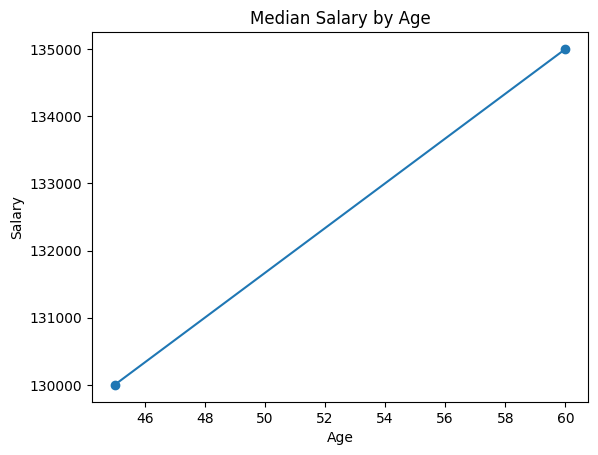

In [42]:
plt.plot(df_line_median['Age'], df_line_median['CompTotal'], marker='o')
plt.title('Median Salary by Age')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


In [43]:
QUERY = """SELECT MainBranch
FROM main
WHERE MainBranch IS NOT NULL;
"""
df_hbar = pd.read_sql_query(QUERY, conn)
df_hbar.value_counts(subset='MainBranch')

MainBranch
I am a developer by profession                                                           50207
I am not primarily a developer, but I write code sometimes as part of my work/studies     6511
I am learning to code                                                                     3875
I code primarily as a hobby                                                               3334
I used to be a developer by profession, but no longer am                                  1510
Name: count, dtype: int64

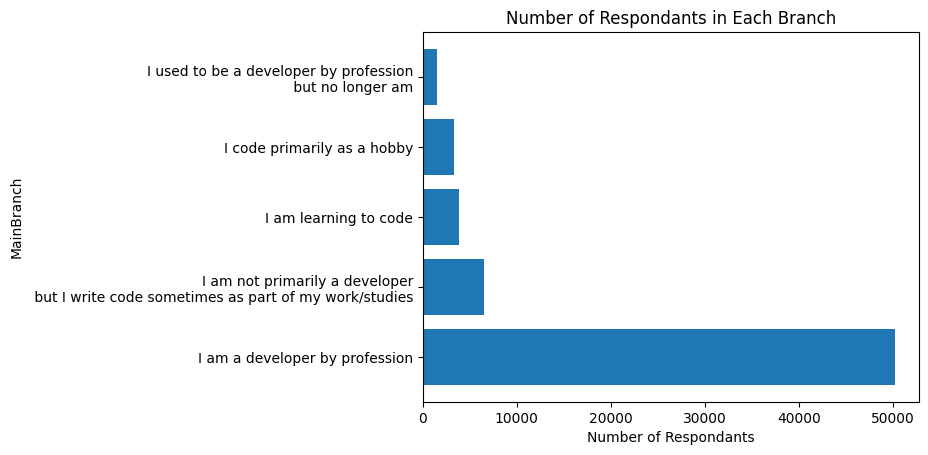

In [44]:
x = list(df_hbar.value_counts(subset='MainBranch').index) # passing subset to avoid multiindex for plotting
wrapped_x = [branch.replace(',', '\n') for branch in x ] # line breaking long string at comma for plotting
y = list(df_hbar.value_counts())

plt.barh(wrapped_x, y)
plt.title('Number of Respondants in Each Branch')
plt.xlabel('Number of Respondants')
plt.ylabel('MainBranch')
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [45]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
